In [766]:
import numpy as np
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Callable
import logging
from StatTools.generators.ndfnoise_generator import ndfnoise
import cv2
import numpy as np
import matplotlib.pyplot as plt
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


@dataclass
class AntConfig:
    """Конфигурация поведения одного муравья."""
    hurst_exponent: float = 0.35 
    movement_scale: float = 2.0  
    repulsion_distance: float = 15.0
    repulsion_strength: float = 0.3
    
    # Размер для рендеринга
    body_length: float = 12.0
    body_width: float = 5.0


@dataclass
class SimulationConfig:
    """Конфигурация симуляции."""
    width: int = 640
    height: int = 480
    num_ants: int = 10
    num_frames: int = 500
    ant_config: AntConfig = field(default_factory=AntConfig)
    seed: Optional[int] = 42


@dataclass
class Ant:
    """Состояние одного муравья."""
    id: int
    x: float
    y: float
    angle: float = 0.0
    speed: float = 0.0





class AntTrajectoryGenerator:
    """
    Генератор траекторий муравьев на основе fGn.
    
    Атрибуты:
        config: Конфигурация симуляции
        ants: Список муравьев
        ground_truth: Ground Truth в формате List[Dict]
    """
    
    def __init__(
        self, 
        config: SimulationConfig
    ):
        self.config = config
        self.rng = np.random.default_rng(config.seed)
        self.ants: List[Ant] = []
        self.ground_truth: List[Dict] = []
        
        
        self._initialize_ants()
        logger.info(
            f"Инициализирован генератор: {config.num_ants} муравьев, "
            f"{config.num_frames} кадров, H={config.ant_config.hurst_exponent:.2f}"
        )
    
    def _initialize_ants(self) -> None:
        """Инициализация муравьев со случайными позициями."""
        margin = 50
        for i in range(self.config.num_ants):
            x = self.rng.uniform(margin, self.config.width - margin)
            y = self.rng.uniform(margin, self.config.height - margin)
            
            ant = Ant(id=i, x=x, y=y)
            self.ants.append(ant)
    
    def _generate_increments(self) -> np.ndarray:
        """
        Генерация приращений для всех муравьев.
        
        Returns:
            Массив shape (num_ants, num_frames, 2) с приращениями (dx, dy)
        """
        cfg = self.config.ant_config
        num_ants = self.config.num_ants
        num_frames = self.config.num_frames
        
        # Генерация приращений для каждого муравья
        increments = np.zeros((num_ants, num_frames, 2))
        
        for i in range(num_ants):
            # Генерируем независимые fGn для x и y
            dx = ndfnoise(shape=(num_frames,), hurst=cfg.hurst_exponent) * cfg.movement_scale
            dy = ndfnoise(shape=(num_frames,), hurst=cfg.hurst_exponent) * cfg.movement_scale
            increments[i, :, 0] = dx
            increments[i, :, 1] = dy
        
        return increments
    
    def _apply_social_forces(
        self, 
        positions: np.ndarray, 
        increments: np.ndarray, 
        frame_idx: int
    ) -> np.ndarray:
        """
        Применение социальных сил (репульсия от соседей).
        
        Args:
            positions: Текущие позиции shape (num_ants, 2)
            increments: Приращения shape (num_ants, 2)
            frame_idx: Индекс текущего кадра
            
        Returns:
            Модифицированные приращения
        """
        cfg = self.config.ant_config
        modified_increments = increments.copy()
        
        num_ants = positions.shape[0]
        
        for i in range(num_ants):
            repulsion_x, repulsion_y = 0.0, 0.0
            
            for j in range(num_ants):
                if i == j:
                    continue
                
                dx = positions[i, 0] - positions[j, 0]
                dy = positions[i, 1] - positions[j, 1]
                dist = np.sqrt(dx**2 + dy**2)
                
                if dist < cfg.repulsion_distance and dist > 0:
                    force_magnitude = cfg.repulsion_strength * (1 - dist / cfg.repulsion_distance)
                    repulsion_x += (dx / dist) * force_magnitude
                    repulsion_y += (dy / dist) * force_magnitude
            
            modified_increments[i, 0] += repulsion_x
            modified_increments[i, 1] += repulsion_y
        
        return modified_increments
    
    def _apply_boundary_conditions(self, positions: np.ndarray) -> np.ndarray:
        """
        Применение граничных условий (отражение).
        
        Args:
            positions: Позиции shape (num_ants, 2)
            
        Returns:
            Модифицированные позиции
        """
        margin = 10
        modified_positions = positions.copy()

        modified_positions[:, 0] = np.clip(modified_positions[:, 0], margin, self.config.width - margin)
        modified_positions[:, 1] = np.clip(modified_positions[:, 1], margin, self.config.height - margin)
        
        return modified_positions
    
    def _calculate_angles(self, increments: np.ndarray) -> np.ndarray:
        """Вычисление углов направления движения."""
        angles = np.arctan2(increments[:, 1], increments[:, 0])
        return angles
    
    def _calculate_speeds(self, increments: np.ndarray) -> np.ndarray:
        """Вычисление скоростей."""
        speeds = np.sqrt(increments[:, 0]**2 + increments[:, 1]**2)
        return speeds
    
    def _record_frame(self, frame_idx: int, positions: np.ndarray, angles: np.ndarray, speeds: np.ndarray) -> None:
        """Запись состояния всех муравьев для текущего кадра."""
        frame_data = {
            'frame': frame_idx,
            'ants': []
        }
        
        for i, ant in enumerate(self.ants):
            frame_data['ants'].append({
                'id': ant.id,
                'x': float(positions[i, 0]),
                'y': float(positions[i, 1]),
                'angle': float(angles[i]),
                'speed': float(speeds[i])
            })
        
        self.ground_truth.append(frame_data)
    
    def generate(self) -> List[Dict]:
        """
        Генерация полной последовательности траекторий.
        
        Returns:
            Ground Truth в формате списка словарей
        """
        logger.info("Начало генерации траекторий...")
        
        
        all_increments = self._generate_increments()
        
       
        positions = np.array([[ant.x, ant.y] for ant in self.ants])
        
        
        for frame_idx in range(self.config.num_frames):
            
            frame_increments = all_increments[:, frame_idx, :]
           
            # frame_increments = self._apply_social_forces(positions, frame_increments, frame_idx)
            
            positions = positions + frame_increments
            
            # positions = self._apply_boundary_conditions(positions)
            
            for i, ant in enumerate(self.ants):
                ant.x = positions[i, 0]
                ant.y = positions[i, 1]
            
            angles = self._calculate_angles(frame_increments)
            speeds = self._calculate_speeds(frame_increments)
            
            self._record_frame(frame_idx, positions, angles, speeds)
            
            
        
        logger.info("Генерация траекторий завершена")
        return self.ground_truth
    
    def get_trajectories_array(self) -> np.ndarray:
        """
        Получение траекторий в виде numpy массива.
        
        Returns:
            Массив shape (num_frames, num_ants, 2) с координатами (x, y)
        """
        trajectories = np.zeros((self.config.num_frames, self.config.num_ants, 2))
        
        for frame_idx, frame_data in enumerate(self.ground_truth):
            for ant_data in frame_data['ants']:
                ant_id = ant_data['id']
                trajectories[frame_idx, ant_id, 0] = ant_data['x']
                trajectories[frame_idx, ant_id, 1] = ant_data['y']
        
        return trajectories


In [767]:

ant_config = AntConfig(
    hurst_exponent=0.8,
    movement_scale=2.0,
    repulsion_distance=15.0,
    repulsion_strength=0.3
)
num_ants = 10
sim_config = SimulationConfig(
    width=500,
    height=500,
    num_ants=num_ants,
    num_frames=10000,
    ant_config=ant_config,
    seed=42
)

# Генерация
generator = AntTrajectoryGenerator(sim_config)
ground_truth = generator.generate()

# Получение массива траекторий
trajectories = generator.get_trajectories_array()

INFO:__main__:Инициализирован генератор: 10 муравьев, 10000 кадров, H=0.80
INFO:__main__:Начало генерации траекторий...
INFO:__main__:Генерация траекторий завершена


In [768]:
import seaborn as sns
colors = sns.color_palette(palette='bright', n_colors=num_ants)
colors = [tuple([int(c*255) for c in color]) for color in colors]

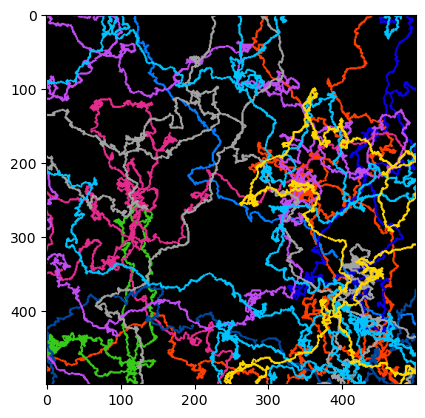

In [769]:
trajectories_round = trajectories.astype(np.int32)
bg = np.zeros(shape=(500, 500, 3), dtype=np.uint8)
trajs = []
for ant in range(trajectories_round.shape[1]):
    trajs.append(np.array([np.array(traj) for traj in trajectories_round[:, ant]]))
for ant, color in  zip(trajs, colors):

    cv2.polylines(bg, [ant], isClosed=False, color=color, thickness=2)

# Display with matplotlib
plt.imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB))
plt.show()
